# Implement continuity equation


In [2]:
import numpy as np
import torch
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import os, warnings
import numpy as np
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")
import numpy as np
import pandas as pd
import numpy as np
import copy
import copy, numpy as np, matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

from fokker_planck import run_fp, plot_fp_density_time_dim, N_I, LAM, KBT, E_A, N_MAX, V_ADV, D
from least_action import solve_optimal_trajectory, compute_least_action, compute_global_hessian_and_det


In [3]:
RECOMPUTE=False

# Result for different c values

In [4]:
if RECOMPUTE:
    c_array = np.logspace(0, 3, 4)
    for c in c_array: 
        fp_ctx = run_fp(
                get_C=lambda t, v: c,
                T=140,
                verbose=False,
            )
        # 1. Extract relevant data for the last time step
        rho_last = fp_ctx['rho_t'][-1]
        axes = fp_ctx['axes']
        S_mat = fp_ctx['S_mat']

        # 2. Reconstruct the grid and calculate the volume element (dH)
        d_h = axes[0][1] - axes[0][0]
        dH = d_h ** len(axes)
        h_mesh = np.meshgrid(*axes, indexing="ij")

        # 3. Calculate affinity (epsilon) for the first antigen (v=0) across the entire grid
        # E_full shape: (n_A, N_h1, N_h2, ...)
        E_full = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
        epsilon = E_full[0].flatten()

        # Convert density to probability mass for accurate binning
        rho_mass_flat = rho_last.flatten() * dH 
        print('total mass check (should be close to N_i):', rho_mass_flat.sum())#is OK

        #save
        df=pd.DataFrame({
            'epsilon': epsilon,
            'rho_epsilon': rho_mass_flat
        })
        
        df.to_csv('rho_epsilon_last_step/rho_epsilon_last_step_c='+str(c)+'.csv')


In [5]:
if RECOMPUTE:
    c_array = [50, 100, 170,200, 500]
    N_MAX_array=[500, 1000, 2500, 5000]
    for c in c_array: 
        for N_MAX in N_MAX_array:
            fp_ctx = run_fp(
                    get_C=lambda t, v: c,
                    T=140,
                    verbose=False,
                    N_MAX=N_MAX,
                    N_I=N_MAX
                )
            # 1. Extract relevant data for the last time step
            rho_last = fp_ctx['rho_t'][-1]
            axes = fp_ctx['axes']
            S_mat = fp_ctx['S_mat']

            # 2. Reconstruct the grid and calculate the volume element (dH)
            d_h = axes[0][1] - axes[0][0]
            dH = d_h ** len(axes)
            h_mesh = np.meshgrid(*axes, indexing="ij")

            # 3. Calculate affinity (epsilon) for the first antigen (v=0) across the entire grid
            # E_full shape: (n_A, N_h1, N_h2, ...)
            E_full = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
            epsilon = E_full[0].flatten()

            # Convert density to probability mass for accurate binning
            rho_mass_flat = rho_last.flatten() * dH 
            print('total mass check (should be close to N_i):', rho_mass_flat.sum())#is OK

            #save
            df=pd.DataFrame({
                'epsilon': epsilon,
                'rho_epsilon': rho_mass_flat
            })
            
            df.to_csv('rho_epsilon_last_step/rho_epsilon_last_step_N_max='+str(N_MAX)+'_c='+str(c)+'.csv')


In [6]:
if RECOMPUTE:
    c_array = [ 10, 50, 100, 170, 500]
    for c in c_array: 
        fp_ctx = run_fp(
                get_C=lambda t, v: c,
                T=140,
                verbose=False
            )
        # 1. Extract relevant data for the last time step
        rho_last = fp_ctx['rho_t'][-1]
        axes = fp_ctx['axes']
        S_mat = fp_ctx['S_mat']

        # 2. Reconstruct the grid and calculate the volume element (dH)
        d_h = axes[0][1] - axes[0][0]
        dH = d_h ** len(axes)
        h_mesh = np.meshgrid(*axes, indexing="ij")

        # 3. Calculate affinity (epsilon) for the first antigen (v=0) across the entire grid
        # E_full shape: (n_A, N_h1, N_h2, ...)
        E_full = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
        epsilon = E_full[0].flatten()

        # Convert density to probability mass for accurate binning
        rho_mass_flat = rho_last.flatten() * dH 
        print('total mass check (should be close to N_i):', rho_mass_flat.sum())#is OK

        #save
        df=pd.DataFrame({
            'epsilon': epsilon,
            'rho_epsilon': rho_mass_flat
        })
        
        df.to_csv('rho_epsilon_last_step/rho_epsilon_last_step_c='+str(c)+'.csv')


# Probability of survival

In [7]:
if RECOMPUTE:
    c_array = np.logspace(-1, 2, 12)  # 10 values from 1 to 1000 on a log scale
    rho_c_array = [0, 1e-7, 1e-5]
    results = {}
    for rho_c in rho_c_array:
        for c in c_array: 
            fp_ctx = run_fp(
                    get_C=lambda t, v: c,
                T=140,
                verbose=False,
                rho_c=rho_c
            )
            # 1. Extract relevant data for the last time step
            rho_last = fp_ctx['rho_t'][-1]
            axes = fp_ctx['axes']
            S_mat = fp_ctx['S_mat']

            # 2. Reconstruct the grid and calculate the volume element (dH)
            d_h = axes[0][1] - axes[0][0]
            dH = d_h ** len(axes)
            h_mesh = np.meshgrid(*axes, indexing="ij")

            # 3. Calculate affinity (epsilon) for the first antigen (v=0) across the entire grid
            # E_full shape: (n_A, N_h1, N_h2, ...)
            E_full = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
            epsilon = E_full[0].flatten()

            # Convert density to probability mass for accurate binning
            rho_mass_flat = rho_last.flatten() * dH 
            print('total mass check (should be close to N_i):', rho_mass_flat.sum())#is 
            #if nan: preplace with 0
            total_pop=rho_mass_flat.sum()
            if np.isnan(total_pop):
                print('NaN detected in total population. Replacing with 0.')
                total_pop = 0.0

            #save total pop
            results[(c, rho_c)] = total_pop

    df_survival = pd.DataFrame([
        {'c': c, 'rho_c': rho_c, 'survival_rate': results[(c, rho_c)] / N_I}
        for rho_c in rho_c_array for c in c_array
    ])

    df_survival.to_csv('survival_rate_fp_log.csv', index=False)
        

# Least actions


Running FP simulation 
Optimal trajectory: (1000,) with shape (2, 1000)


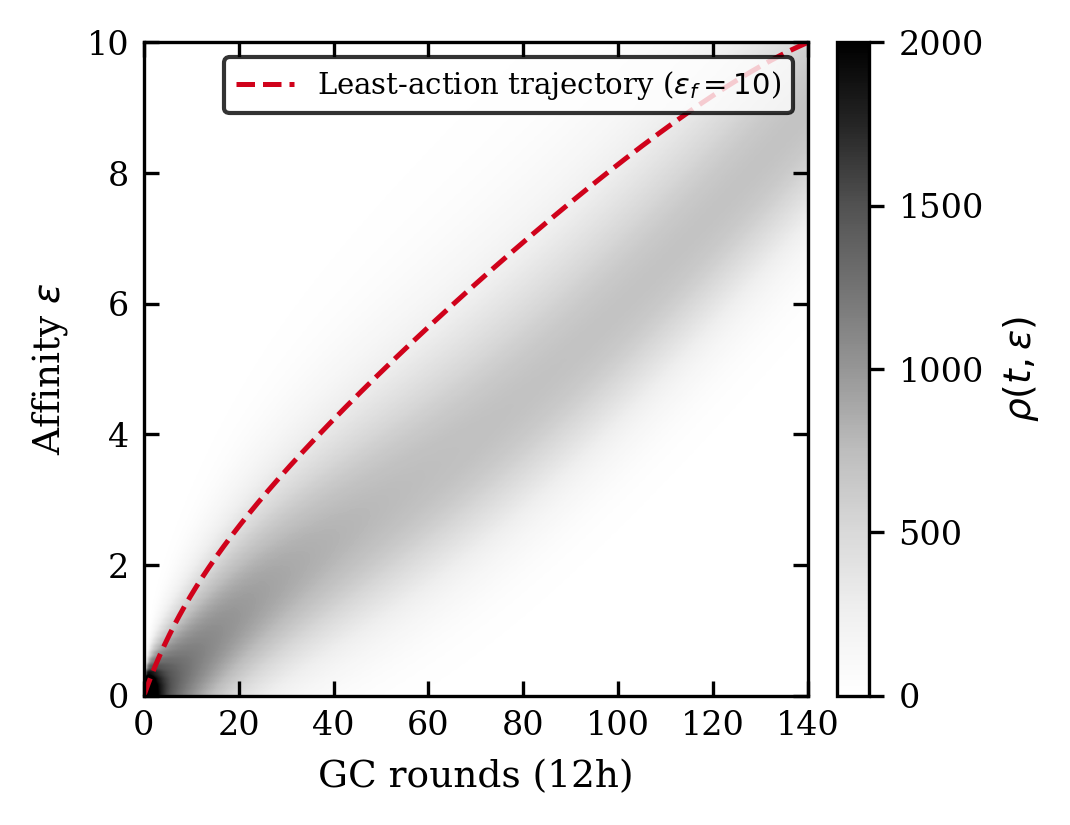

In [9]:
print(f"\nRunning FP simulation ")

fp_ctx = run_fp(
        get_C=lambda t, v: 170.0,
        # T=140,
        verbose=False
    )

t=10
fp_ctx_safe = copy.deepcopy(fp_ctx)
sol = solve_optimal_trajectory([t], fp_ctx_safe)
print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
plot_fp_density_time_dim(fp_ctx, sol=sol, disp_step=20, ymax=10, leastaction_label=r"Least-action trajectory ($\epsilon_f=10$)")


In [11]:

if RECOMPUTE:
    for t in [3,4,5,6,7,8,9,10]:

        fp_ctx_safe = copy.deepcopy(fp_ctx)
        sol = solve_optimal_trajectory([t], fp_ctx_safe)
        print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
        S, _ = compute_least_action(sol, fp_ctx, verbose=True)

        np.savetxt(f"trajectory_h_140/trajectory_h_140_{t}.csv", sol.y[0], delimiter=",")
        print("Saved sol.y[0] to trajectory_h.csv")




In [12]:
if RECOMPUTE:
    c_array = [ 50, 100,200, 500]
    targets=[2,4,6,8,10, 12, 16, 18]
    results = {}
    for c in c_array:
        fp_ctx = run_fp(
                        get_C=lambda t, v: c,
                    T=140,
                    verbose=False,
                )
        S_vals=[]

        for t in targets:
            fp_ctx_safe = copy.deepcopy(fp_ctx)
            sol = solve_optimal_trajectory([t], fp_ctx_safe)
            print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
            S, _ = compute_least_action(sol, fp_ctx, verbose=True)
            S_vals.append(S)
        results[c] = S_vals

    #save a csv of results
    df_S = pd.DataFrame({
        'C': np.repeat(c_array, len(S_vals)),
        't': np.tile(targets, len(c_array)),
        'S': np.concatenate(list(results.values()))
    })
    df_S.to_csv('S_values_with_C.csv', index=False)

        




In [13]:
if RECOMPUTE:
    c_array = [ 50, 100,200, 500]
    targets=[2,4,6,8,10, 12, 16, 18]
    results = {}
    for c in c_array:
        fp_ctx = run_fp(
                        get_C=lambda t, v: c,
                    T=140,
                    verbose=False,
                )
        h_axis    = fp_ctx["axes"][0]
        rho_final = fp_ctx["rho_t"][-1].squeeze()

        # ------------------------------------------------------------------
        # 1.  Sample 20 starting points in [0, 10]
        # ------------------------------------------------------------------


        log_rho_grid = np.log(rho_final + 1e-12)
        log_rho_samp = np.interp(targets, h_axis, log_rho_grid)
        results[c] = log_rho_samp

    #save a csv of results
    df_log_rho = pd.DataFrame({
        'C': np.repeat(c_array, len(targets)),
        't': np.tile(targets, len(c_array)),
        'log_rho': np.concatenate(list(results.values()))
    })
    df_log_rho.to_csv('log_rho_values_with_C.csv', index=False)




In [14]:
df_log_rho = pd.read_csv('log_rho_values_with_C.csv')
df_S = pd.read_csv('S_values_with_C.csv')

log_rho_samp = df_log_rho['log_rho'].values
S_vals = df_S['S'].values
targets = df_S['t'].values


[100 200 500]


100
200
500


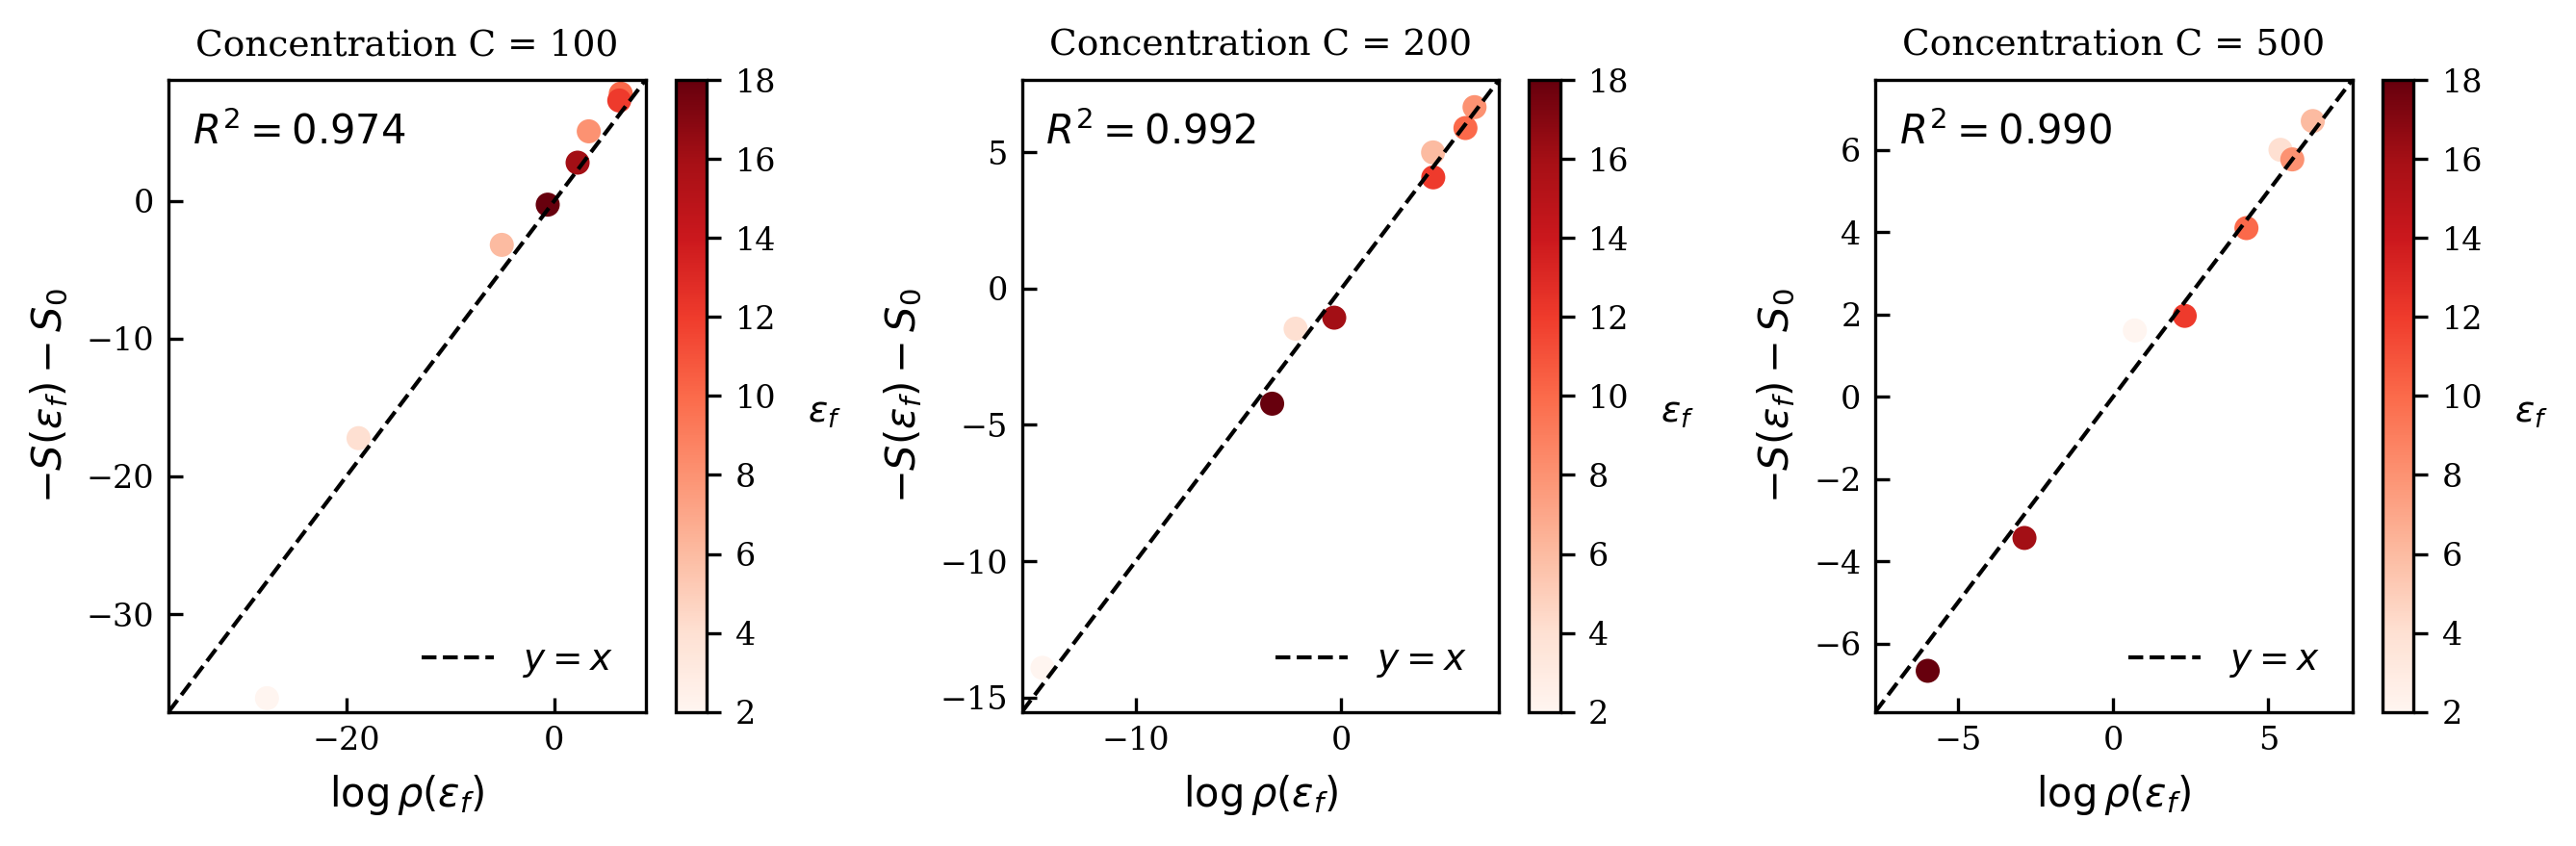

In [ ]:


# Load the data
df_S = pd.read_csv('S_values_with_C.csv')
df_log_rho = pd.read_csv('log_rho_values_with_C.csv')

# Merge dataframes on Concentration (C) and target (t) to ensure perfect alignment
df_merged = pd.merge(df_S, df_log_rho, on=['C', 't'])

# Get unique concentrations
concentrations = np.sort(df_merged['C'].unique()[1:])
print(concentrations)

# Create 1x3 subplots 
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=False)

# Ensure axes is iterable even if there happens to be fewer than 3 concentrations
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

# Loop over the first 3 concentrations
for i, (ax, c_val) in enumerate(zip(axes, concentrations)):
    print (c_val)
  
    
    # Filter for the current concentration
    df_sub = df_merged[df_merged['C'] == c_val].reset_index(drop=True)
    
    # Extract values as numpy arrays
    x_vals = df_sub['log_rho'].values
    S_vals = df_sub['S'].values
    t_vals = df_sub['t'].values  # This is epsilon_f, used for coloring
    
    # Apply unary minus to S_vals
    y_vals_raw = -S_vals
    
    # Fit regression (Used for R^2 calculation)
    slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals_raw)
    r_squared = r_value**2
    
    # Calculate shift (S0) to center data on y=x (Mean difference)
    shift = np.mean(y_vals_raw - x_vals)
    
    # Plot shifted data (y - shift)
    y_vals_shifted = y_vals_raw - shift
    sc = ax.scatter(x_vals, y_vals_shifted, c=t_vals, cmap="Reds", edgecolors="none")
    
    # --- Find and Annotate Most Probable epsilon_f ---
    # The most probable epsilon_f corresponds to the maximum log_rho (x_vals)
    max_idx = np.argmax(x_vals)
    max_x = x_vals[max_idx]
    max_y = y_vals_shifted[max_idx]
    max_eps = t_vals[max_idx]
    

    
    # --- Add y=x line ---
    # Determine bounds to make the diagonal line span the plot beautifully
    min_val = min(x_vals.min(), y_vals_shifted.min()) - 1
    max_val = max(x_vals.max(), y_vals_shifted.max()) + 1
    line_range = np.linspace(min_val, max_val, 100)
    ax.plot(line_range, line_range, 'k--', linewidth=1, label=r"$y=x$")
    
    # --- Add R^2 text ---
    ax.text(0.05, 0.95, f"$R^2={r_squared:.3f}$", transform=ax.transAxes, 
            fontsize=10, verticalalignment='top')
    
    # --- Formatting ---
    ax.set_title(f"Concentration C = {c_val}")
    ax.set_xlabel(r"$\log \rho(\epsilon_f)$")
    
    if i == 0:
        ax.set_ylabel(r"$-S(\epsilon_f) - S_0$")
        
    ax.tick_params(direction="in")
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val) # Matching ylim to xlim makes y=x diagonal perfect
    ax.set_ylabel(r"$-S(\epsilon_f) - S_0$", fontsize=10)
    ax.set_xlabel(r"$\log \rho(\epsilon_f)$", fontsize=10)
    ax.legend(frameon=False, fontsize=9, loc='lower right')
    
    # Colorbar for epsilon_f
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(r"$\epsilon_f$", rotation=0, labelpad=12)

fig.tight_layout()
plt.show()


Running FP simulation for T=140 seconds


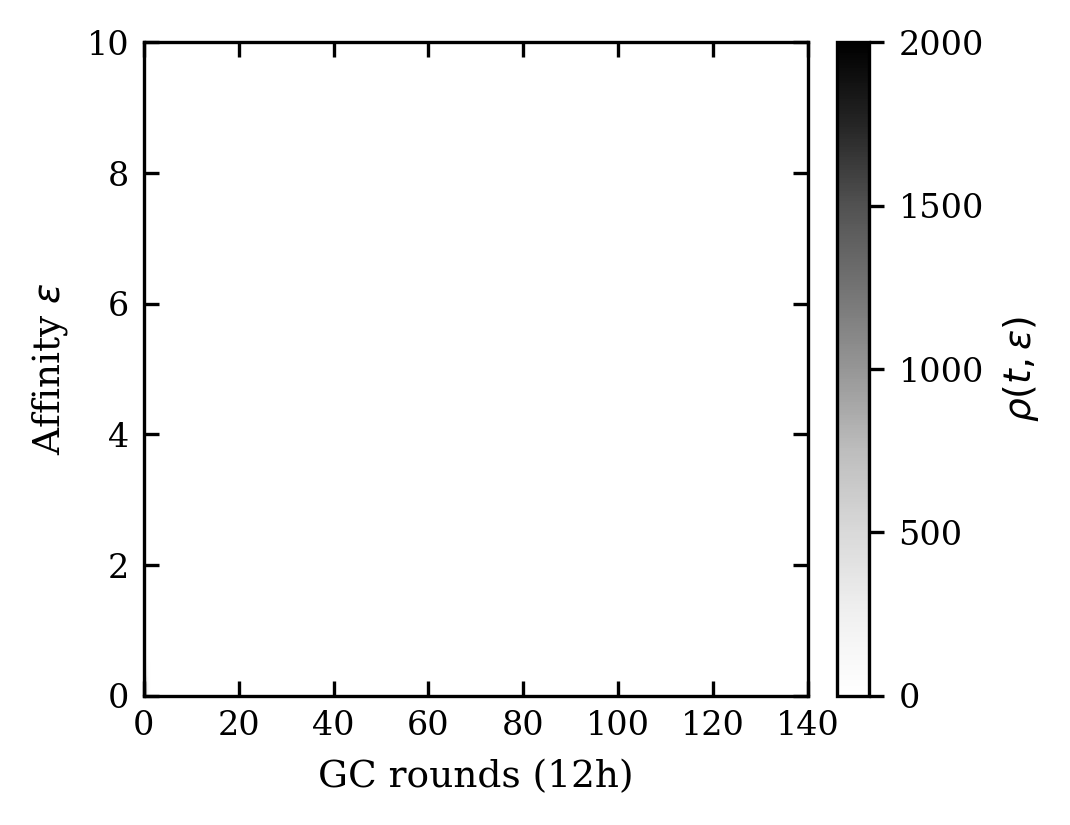


Running FP simulation for T=140 seconds


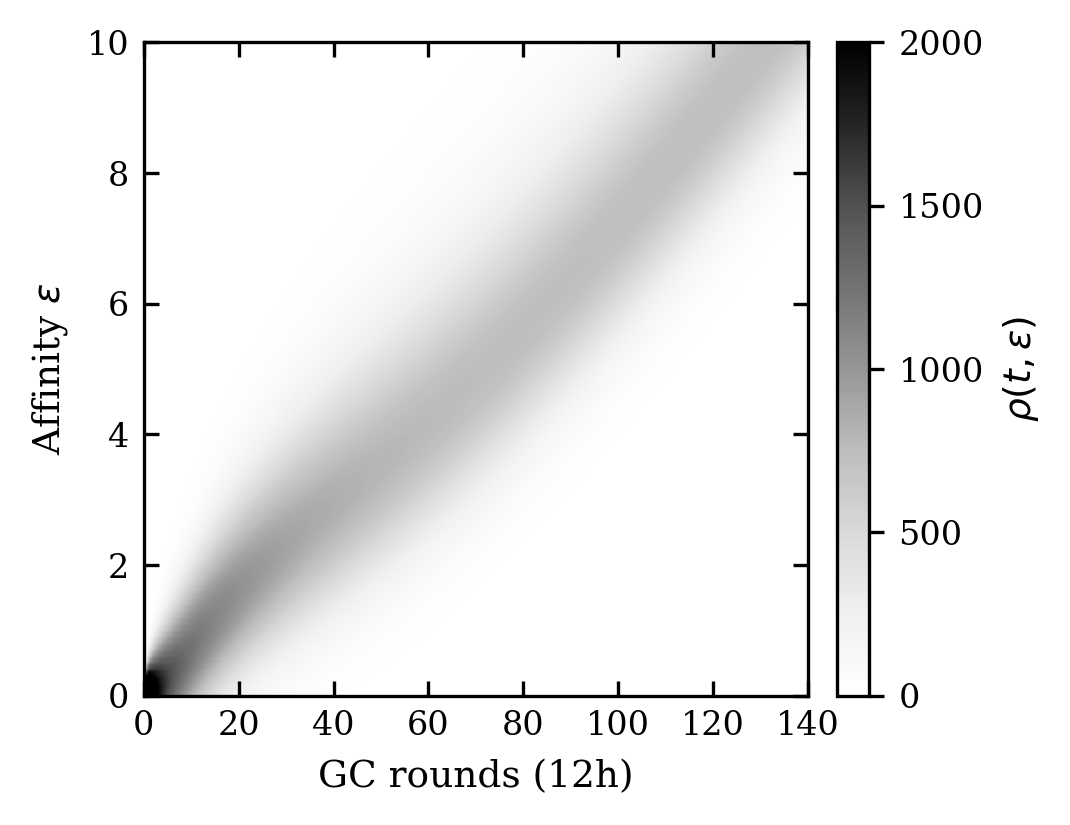


Running FP simulation for T=140 seconds


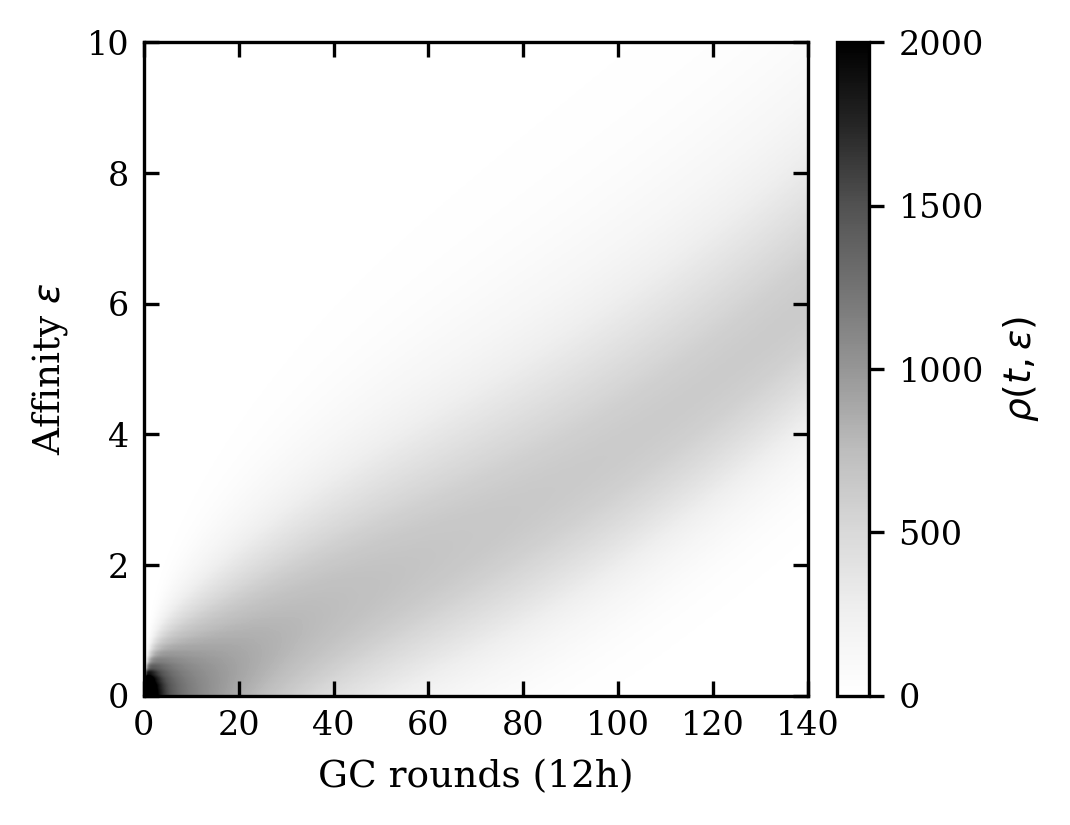

In [ ]:

T=140
for c in [1,100, 500]:
    print(f"\nRunning FP simulation for T={T} seconds")
    fp_ctx = run_fp(
        get_C=lambda t, v: c,
        verbose=False,
    )
    plot_fp_density_time_dim(fp_ctx, sol=None, disp_step=20, ymax=10)

# Least action analysis

In [28]:
c=170

In [29]:


# ------------------------------------------------------------------
# 0.  Run FP once  (your run_fp definition must be in scope)
# ------------------------------------------------------------------
fp_ctx = run_fp(
    # S_mat=np.array([[1.0]]),
    get_C=lambda t, v: c,
    # T=140.0,
    verbose=False
)

h_axis    = fp_ctx["axes"][0]
rho_final = fp_ctx["rho_t"][-1].squeeze()

# ------------------------------------------------------------------
# 1.  Sample 20 starting points in [0, 10]
# ------------------------------------------------------------------
h_min, h_max = 4.0, 14.0
h_samples = np.linspace(h_min, h_max, 10)

log_rho_grid = np.log(rho_final + 1e-12)
log_rho_samp = np.interp(h_samples, h_axis, log_rho_grid)

S_vals = np.empty_like(h_samples)

# ------------------------------------------------------------------
# 2.  Compute least-action values
# ------------------------------------------------------------------
for i, h0 in enumerate(h_samples):
    fp_ctx_i = copy.copy(fp_ctx)
    sol_i    = solve_optimal_trajectory([h0], fp_ctx_i)
    S_i, _   = compute_least_action(sol_i, fp_ctx_i, verbose=False)
    S_vals[i] = S_i




# Entropic correction

In [32]:

# -------------------------------------------------------------------------
# 1. Compute Loops
# -------------------------------------------------------------------------
# Initialize arrays to store results
# S_opt_vals  = np.zeros(len(h_samples))
if RECOMPUTE:
    c_array = [ 50, 100,200, 500]
    targets=[2,4,6,8,10, 12, 16, 18]
    results = {}
    for c in c_array:
        E_vals=[]
        fp_ctx = run_fp(
                        get_C=lambda t, v: c,
                    T=140,
                    verbose=False,
                )
        S_corr_vals = np.zeros(len(targets))

        print(f"Processing {len(targets)} samples...")

        for i, h_target in enumerate(targets):
            # Create a context copy for this iteration
            fp_ctx_i = copy.copy(fp_ctx)
            
            # Solve the BVP for the specific target affinity (h_target)
            # Assuming solve_optimal_trajectory takes a list/array for the boundary condition
            sol_i = solve_optimal_trajectory([h_target], fp_ctx_i)
            
            # Compute Action and Entropic Correction using the new function
            # Returns: (S_opt, S_corrected)
            # s_opt, s_corr = compute_s_opt_and_s_corr(sol_i, fp_ctx_i, verbose=True)
            logdet, H_global=compute_global_hessian_and_det(sol_i, fp_ctx, verbose=True)
            # S_opt_vals[i]  = s_opt
            rep = logdet/2
            E_vals.append(rep)
        results[c] = E_vals

    df_S = pd.DataFrame({
    'C': np.repeat(c_array, len(S_vals)),
    't': np.tile(targets, len(c_array)),
    'Entropy': np.concatenate(list(results.values()))
})
    df_S.to_csv('Entropic_values_with_C.csv', index=False)



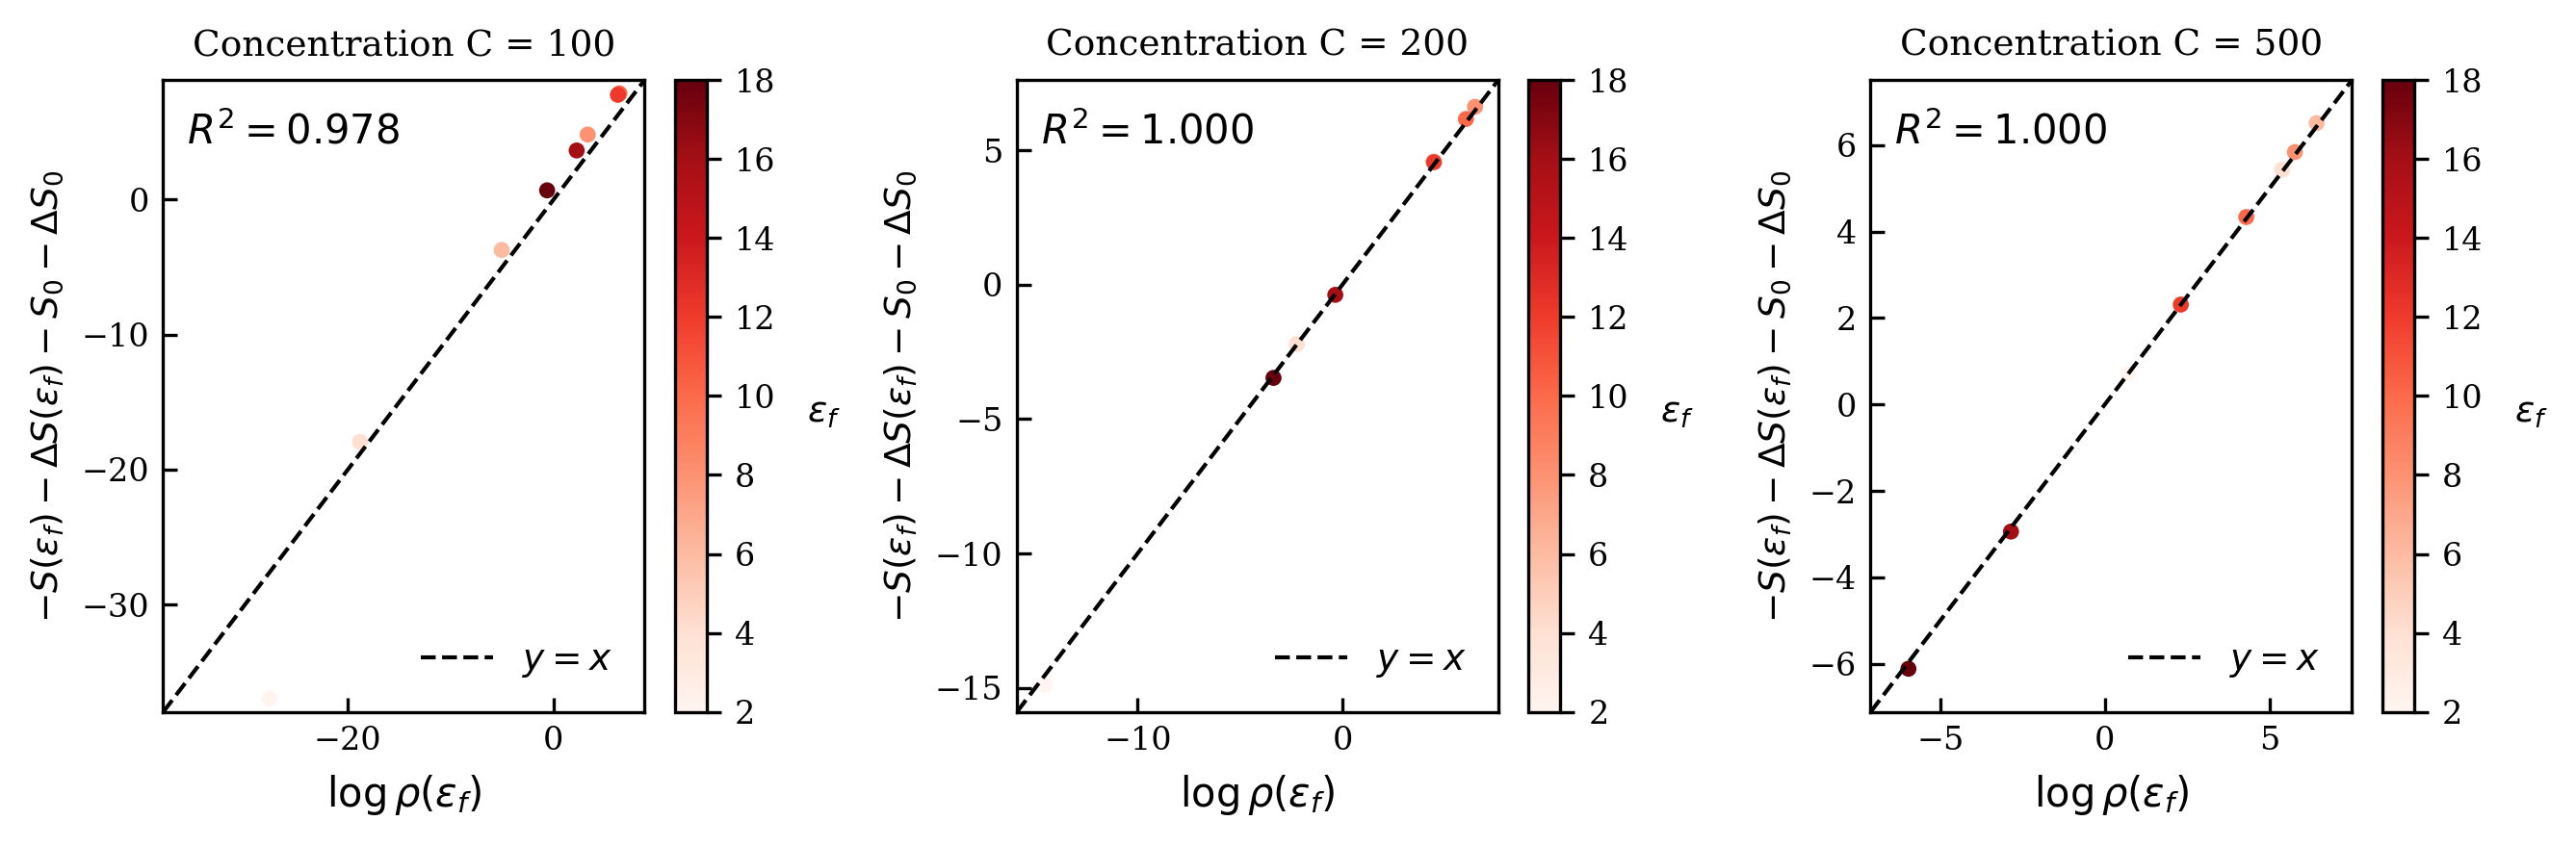

In [33]:


# Load the data
df_S = pd.read_csv('S_values_with_C.csv')
df_E=pd.read_csv('Entropic_values_with_C.csv')
df_log_rho = pd.read_csv('log_rho_values_with_C.csv')

# Merge dataframes on Concentration (C) and target (t) to ensure perfect alignment
df_merged = pd.merge(df_S, df_log_rho, on=['C', 't'])
df_merged=pd.merge(df_merged, df_E, on=['C', 't'])

# Get unique concentrations
concentrations = np.sort(df_merged['C'].unique())[1:]

# Create 1x3 subplots 
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=False)

# Ensure axes is iterable even if there happens to be fewer than 3 concentrations
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

# Loop over the first 3 concentrations
for i, (ax, c_val) in enumerate(zip(axes, concentrations[:3])):
    
    # Filter for the current concentration
    df_sub = df_merged[df_merged['C'] == c_val].reset_index(drop=True)
    
    # Extract values as numpy arrays
    x_vals = df_sub['log_rho'].values
    S_vals_c = df_sub['S'].values
    E_vals_c = df_sub['Entropy'].values




    t_vals = df_sub['t'].values  # This is epsilon_f, used for coloring
    
    # Apply unary minus to S_vals_c
    y_vals_raw = -S_vals_c-E_vals_c
    
    # Fit regression (Used for R^2 calculation)
    slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals_raw)
    r_squared = r_value**2
    
    # Calculate shift (S0) to center data on y=x (Mean difference)
    shift = np.mean(y_vals_raw - x_vals)
    
    # Plot shifted data (y - shift)
    y_vals_shifted = y_vals_raw - shift
    sc = ax.scatter(x_vals, y_vals_shifted, c=t_vals, cmap="Reds", edgecolors="none")
    
    # --- Find and Annotate Most Probable epsilon_f ---
    # The most probable epsilon_f corresponds to the maximum log_rho (x_vals)
    max_idx = np.argmax(x_vals)
    max_x = x_vals[max_idx]
    max_y = y_vals_shifted[max_idx]
    max_eps = t_vals[max_idx]
    
    # # Add arrow and text pointing to the maximum point
    # ax.annotate(f"Most probable\n$\\epsilon_f={max_eps}$", 
    #             xy=(max_x, max_y), 
    #             xytext=(-70, -50), textcoords="offset points", # Offset by points to avoid axis scaling issues
    #             arrowprops=dict(facecolor='black', arrowstyle="->", connectionstyle="arc3,rad=.2"),
    #             fontsize=9,
    #             horizontalalignment='center')
    
    # --- Add y=x line ---
    # Determine bounds to make the diagonal line span the plot beautifully
    min_val = min(x_vals.min(), y_vals_shifted.min()) - 1
    max_val = max(x_vals.max(), y_vals_shifted.max()) + 1
    line_range = np.linspace(min_val, max_val, 100)
    ax.plot(line_range, line_range, 'k--', linewidth=1, label=r"$y=x$")
    
    # --- Add R^2 text ---
    ax.text(0.05, 0.95, f"$R^2={r_squared:.3f}$", transform=ax.transAxes, 
            fontsize=10, verticalalignment='top')
    
    # --- Formatting ---
    ax.set_title(f"Concentration C = {c_val}")
    ax.set_xlabel(r"$\log \rho(\epsilon_f)$")
    
    # if i == 0:
        # ax.set_ylabel(r"$-S(\epsilon_f) -\Delta S(\epsilon_f) - S_0$ -\Delta S_0")
    ax.tick_params(direction="in")
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val) # Matching ylim to xlim makes y=x diagonal perfect
    # ax.set_ylabel(r"$-S(\epsilon_f) - S_0$", fontsize=10)
    ax.set_xlabel(r"$\log \rho(\epsilon_f)$", fontsize=10)
    ax.set_ylabel(r"$-S(\epsilon_f) -\Delta S(\epsilon_f) - S_0 -\Delta S_0$")

    ax.legend(frameon=False, fontsize=9, loc='lower right')
    
    # Colorbar for epsilon_f
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(r"$\epsilon_f$", rotation=0, labelpad=12)

fig.tight_layout()
plt.show()

In [34]:
c=170
fp_ctx = run_fp(
    # S_mat=np.array([[1.0]]),
    get_C=lambda t, v: c,
    # T=140.0,
    verbose=False
)

h_axis    = fp_ctx["axes"][0]
rho_final = fp_ctx["rho_t"][-1].squeeze()

# ------------------------------------------------------------------
# 1.  Sample 20 starting points in [0, 10]
# ------------------------------------------------------------------
h_min, h_max = 4.0, 14.0
h_samples = np.linspace(h_min, h_max, 10)

log_rho_grid = np.log(rho_final + 1e-12)
log_rho_samp = np.interp(h_samples, h_axis, log_rho_grid)
# -------------------------------------------------------------------------
# 1. Compute Loops
# -------------------------------------------------------------------------
# Initialize arrays to store results
# S_opt_vals  = np.zeros(len(h_samples))
S_corr_vals = np.zeros(len(h_samples))

print(f"Processing {len(h_samples)} samples...")

for i, h_target in enumerate(h_samples):
    # Create a context copy for this iteration
    fp_ctx_i = copy.copy(fp_ctx)
    
    # Solve the BVP for the specific target affinity (h_target)
    # Assuming solve_optimal_trajectory takes a list/array for the boundary condition
    sol_i = solve_optimal_trajectory([h_target], fp_ctx_i)
    
    # Compute Action and Entropic Correction using the new function
    # Returns: (S_opt, S_corrected)
    # s_opt, s_corr = compute_s_opt_and_s_corr(sol_i, fp_ctx_i, verbose=True)
    logdet, H_global=compute_global_hessian_and_det(sol_i, fp_ctx, verbose=True)
    # S_opt_vals[i]  = s_opt
    S_corr_vals[i] = logdet/2



Processing 10 samples...
--- Constructing Hessian ---
Time steps: 1000, Variables: 998, Total Matrix Size: 998x998
Kinetic Diagonal Base: 2.00

Global Hessian (Top-Left 10x10 snippet):
[[ 1. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  2. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  2. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  2. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  2. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  2. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.  2. -1.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. -1.  2.]]

Global Hessian (Bottom-Right 6x6 snippet):
[[ 2. -1.  0.  0.  0.  0.]
 [-1.  2. -1.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.]
 [ 0.  0.  0. -1.  2. -1.]
 [ 0.  0.  0.  0. -1.  2.]]
----------------------------------------
Log Determinant: 6.082683
Sign: 1.0
----------------------------------------
--- Constructing Hessian ---
Time steps: 1000, Variables: 9

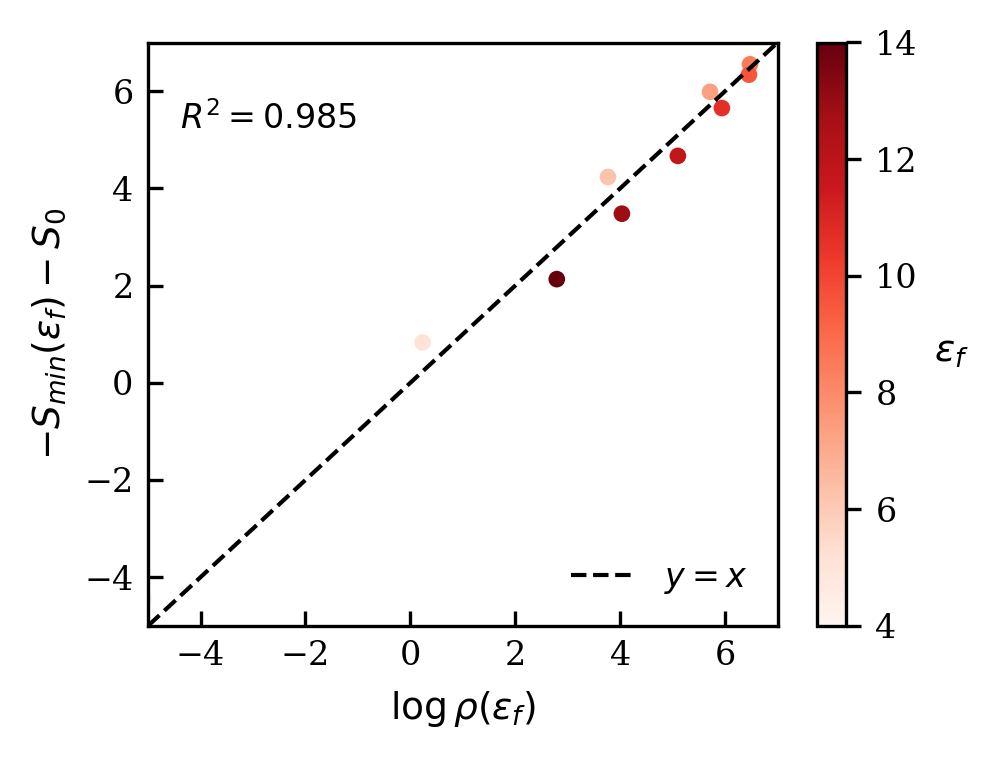

In [40]:

rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
})
fig, ax = plt.subplots()

# --- Data Preparation (Series 2: S_min only) ---
y_vals = 0 + (-S_vals)
x_vals = log_rho_samp

# Fit regression (Used only for R^2 calculation now)
slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals)
r_squared = r_value**2

# Calculate shift to center data on y=x (Mean difference)
shift = np.mean(y_vals - x_vals)

# Plot shifted data (y - shift)
sc = ax.scatter(x_vals, y_vals - shift, c=h_samples, cmap="Reds", 
                edgecolors="none")

# --- Add y=x line ---
# Create a range for the line based on the axis limits
line_range = np.linspace(-5, 7, 100)
ax.plot(line_range, line_range, 'k--', linewidth=1, label=r"$y=x$")

# --- Add R^2 text ---
# Placing text inside the plot area
ax.text(0.05, 0.9, f"$R^2={r_squared:.3f}$", transform=ax.transAxes, 
        fontsize=8, verticalalignment='top')

# --- Formatting ---
ax.legend(frameon=False, fontsize=8, loc='lower right')

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\epsilon_f$", rotation=0, labelpad=8)

ax.set_xlabel(r"$\log \rho(\epsilon_f)$")
ax.set_ylabel(r"$-S_{min}(\epsilon_f)-S_0$")
ax.tick_params(direction="in")
ax.grid(False)
plt.xlim(-5, 7)
plt.ylim(-5, 7) # Matching ylim to xlim makes y=x appear clearly as a diagonal

fig.tight_layout()
plt.show()

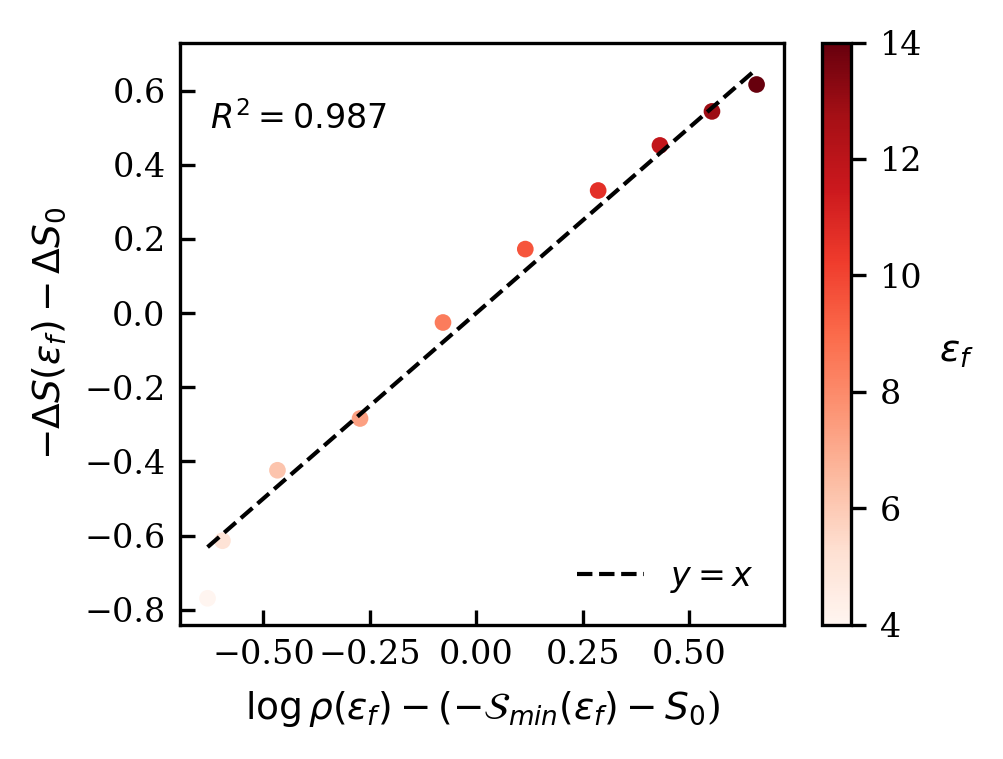

In [41]:


fig, ax = plt.subplots()

# --- Data Preparation ---
x_vals = log_rho_samp - (-S_vals-shift)
y_vals = -S_corr_vals

# --- 1. Linear Regression (Just for R^2 statistics) ---
slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals)
r_squared = r_value**2

# --- 2. Calculate Alignment Shift ---
# Instead of subtracting the regression intercept, we subtract the mean difference.
# This forces the center of the data mass to lie exactly on y=x.
shift2 = np.mean(y_vals - x_vals) 
y_shifted = y_vals - shift2

# --- Plotting ---
sc = ax.scatter(x_vals, y_shifted, c=h_samples, cmap="Reds", edgecolors="none")

# Add y=x reference line
line_range = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(line_range, line_range, 'k--', linewidth=1, label=r"$y=x$")

# Add R^2 and Slope text annotation
# It is useful to note the slope is != 1
text_str = f"$R^2={r_squared:.3f}$"
ax.text(0.05, 0.9, text_str, transform=ax.transAxes, 
        fontsize=8, verticalalignment='top', )

# --- Formatting ---
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\epsilon_f$", rotation=0, labelpad=8)

ax.set_ylabel(r"$-\Delta S(\epsilon_f) -\Delta S_0$")
ax.set_xlabel(r"$\log \rho(\epsilon_f)-(-\mathcal{S}_{min}(\epsilon_f)-S_0$)")
ax.tick_params(direction="in")
ax.grid(False)
ax.legend(frameon=False, fontsize=8, loc='lower right')

fig.tight_layout()
plt.show()

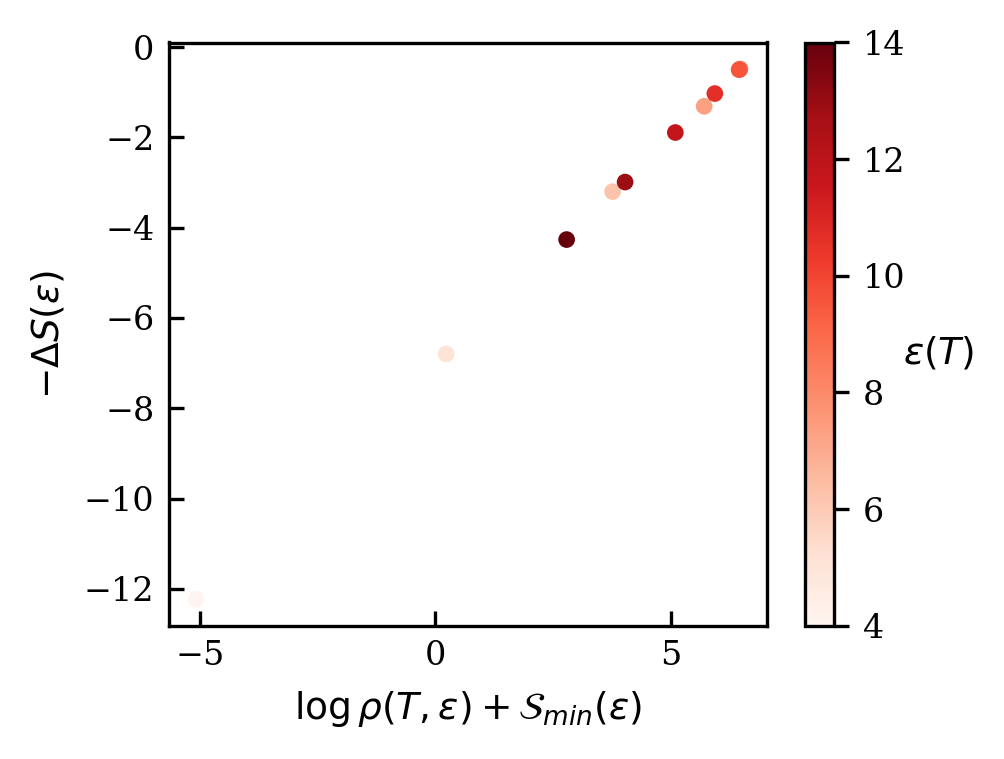

In [42]:
fig, ax = plt.subplots()
sc = ax.scatter(log_rho_samp, -S_vals-S_corr_vals ,c=h_samples, cmap="Reds", edgecolors="none")
# sc = ax.scatter(h_samples,log_rho_samp-(-S_vals+np.log(N_i)), c=h_samples, cmap="Reds", edgecolors="none")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\epsilon(T)$", rotation=0, labelpad=8)

ax.set_ylabel(r"$-\Delta S(\epsilon)$")
ax.set_xlabel(r"$\log \rho(T,\epsilon)+\mathcal{S}_{min}(\epsilon)$")
# ax.set_title(r"Entropic correction")
ax.tick_params(direction="in")
ax.grid(False)

fig.tight_layout()
plt.show()